# 03 · คำถามข้อ 1 ถึง 3: ชั่วโมงใช้งานและการติดตามข่าว กับคะแนนสามมิติ

เค้าโครงถามถึง "สุขภาพจิต" เป็นก้อนเดียว แต่ DASS-21 วัดสามมิติแยกกัน
คำถามจึงทดสอบได้ก็ต่อเมื่อระบุว่าโซเชียลมีเดียเกี่ยวกับมิติใด
ตัวแปรต้นมีสองแบบ คือ **ปริมาณ** (`social_media_hours` ชั่วโมงต่อวัน) และ **ประเภทเนื้อหา** (`news_days` จำนวนวันที่ติดตามข่าวต่อสัปดาห์)

In [1]:
import os
import pathlib
import sys

# notebook.nvim starts the kernel in nvim's cwd; step into codingpy/ so common.py
# and data/ are found when the notebook is opened from the repo root
if pathlib.Path("codingpy/common.py").is_file():
    os.chdir("codingpy")
    sys.path.insert(0, os.getcwd())

%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from common import (
    COLOR,
    DIMENSION_TH,
    DIMENSIONS,
    FIG_DIR,
    N_BOOT,
    SEED,
    THAI_FONT,
    TITLE_SIZE,
    load_data,
    passed_attention,
)

df = passed_attention(load_data())  # the sample every research question uses
print(f"{len(df)} respondents passed the attention check")

107 respondents passed the attention check


## 3.1 ดูข้อมูลก่อน: scatter plot

เริ่มจากจุดของผู้ตอบแต่ละคน พร้อมสหสัมพันธ์เพียร์สัน r และ r² (สัดส่วนความแปรปรวนที่อธิบายได้)

In [3]:
def pearson_by_dimension(df: pd.DataFrame, exposure: str) -> None:
    for col, name in DIMENSIONS.items():
        d = df[[exposure, col]].dropna()
        r, p = stats.pearsonr(d[exposure], d[col])
        print(f"{name}: r = {r:.3f}, r^2 = {r**2:.3f}, p = {p:.4f}, n = {len(d)}")


def scatter_by_dimension(df: pd.DataFrame, exposure: str, xlabel: str, fig_path) -> None:
    plt.rcParams["font.family"] = THAI_FONT
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
    for ax, (col, name) in zip(axes, DIMENSIONS.items()):
        ax.scatter(df[exposure], df[col], alpha=0.6)
        ax.set_title(name)
        ax.set_xlabel(xlabel)
    axes[0].set_ylabel("คะแนน DASS-21 (0-42)")
    fig.tight_layout()
    fig.savefig(fig_path, dpi=200, facecolor="white")
    print(f"Saved: {fig_path}")
    plt.show()

**ข้อ 1** ชั่วโมงใช้โซเชียลมีเดียต่อวัน กับคะแนนสามมิติ

Depression: r = -0.136, r^2 = 0.019, p = 0.1615, n = 107
Anxiety: r = -0.148, r^2 = 0.022, p = 0.1293, n = 107
Stress: r = -0.087, r^2 = 0.007, p = 0.3755, n = 107


Saved: ../figures/q1-usage-dass.png


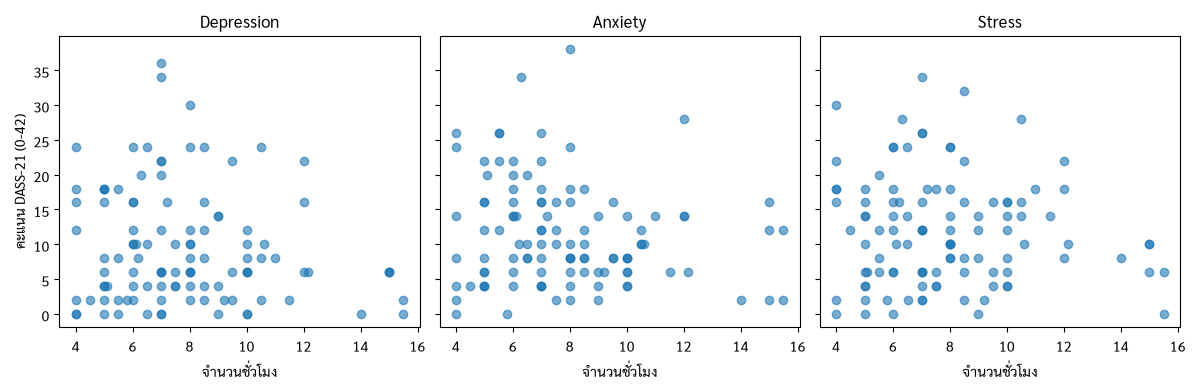

In [4]:
pearson_by_dimension(df, "social_media_hours")
scatter_by_dimension(df, "social_media_hours", "จำนวนชั่วโมง", FIG_DIR / "q1-usage-dass.png")

**ข้อ 3** จำนวนวันที่ติดตามข่าวต่อสัปดาห์ กับคะแนนสามมิติ

Depression: r = -0.013, r^2 = 0.000, p = 0.8919, n = 107
Anxiety: r = 0.146, r^2 = 0.021, p = 0.1344, n = 107
Stress: r = 0.101, r^2 = 0.010, p = 0.3030, n = 107


Saved: ../figures/q3-news-anxiety.png


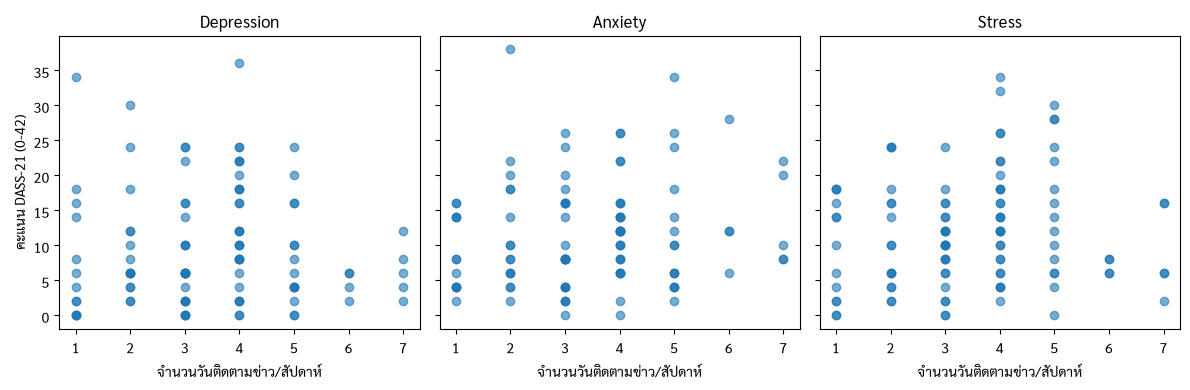

In [5]:
pearson_by_dimension(df, "news_days")
scatter_by_dimension(df, "news_days", "จำนวนวันติดตามข่าว/สัปดาห์", FIG_DIR / "q3-news-anxiety.png")

## 3.2 ตารางสหสัมพันธ์พร้อมช่วงความเชื่อมั่นและ partial r

แต่ละคู่ (ตัวแปรต้น × มิติ) รายงาน

- **r** สหสัมพันธ์เพียร์สัน พร้อมช่วงความเชื่อมั่น 95% แบบ percentile bootstrap (สุ่มผู้ตอบซ้ำทั้งคู่ 5,000 รอบ)
- **rho** สหสัมพันธ์สเปียร์แมน ไว้ตรวจว่าผลไม่ได้มาจากค่าสุดโต่งไม่กี่จุด
- **partial r** สหสัมพันธ์หลังหักผลของชั่วโมงนอน คุณภาพการนอน ความกดดันจากการเรียน เกรดเฉลี่ย และความเพียงพอทางการเงิน
  ออกจากทั้งสองตัวแปร ถ้าความสัมพันธ์เป็นแค่เงาของการนอนน้อย ค่า partial r จะยุบเข้าหาศูนย์

In [6]:
EXPOSURE_LABELS = {
    "social_media_hours": "Daily use (hours/day)",
    "news_days": "News content (days/week)",
}
EXPOSURE_TH = {
    "Daily use (hours/day)": "ใช้โซเชียลกี่ชั่วโมงต่อวัน",
    "News content (days/week)": "เสพข่าวกี่วันต่อสัปดาห์",
}

# confounders held fixed in the partial correlation
PARTIAL_CONTROLS = [
    "sleep_hours",
    "sleep_quality",
    "study_pressure",
    "GPA",
    "financial_sufficiency",
]


def residuals(y: np.ndarray, controls: pd.DataFrame) -> np.ndarray:
    """What is left of y once the control columns have explained what they can."""
    X = np.column_stack([np.ones(len(controls)), controls.to_numpy(dtype=float)])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ beta


def partial_r(df: pd.DataFrame, x_col: str, y_col: str) -> tuple[float, float, int]:
    """Pearson r between x and y after both are regressed on PARTIAL_CONTROLS."""
    d = df[[x_col, y_col] + PARTIAL_CONTROLS].dropna()
    x = residuals(d[x_col].to_numpy(dtype=float), d[PARTIAL_CONTROLS])
    y = residuals(d[y_col].to_numpy(dtype=float), d[PARTIAL_CONTROLS])
    # two control-fitting steps cost 2 df, so the p-value is taken from t with
    # n - len(PARTIAL_CONTROLS) - 2 df rather than from stats.pearsonr's n - 2
    r = float(np.corrcoef(x, y)[0, 1])
    dof = len(d) - len(PARTIAL_CONTROLS) - 2
    t = r * np.sqrt(dof / max(1 - r**2, 1e-12))
    return r, float(2 * stats.t.sf(abs(t), dof)), len(d)


def boot_ci(x: np.ndarray, y: np.ndarray, rng: np.random.Generator) -> tuple[float, float]:
    """Percentile bootstrap 95% CI for Pearson r, resampling respondents in pairs."""
    idx = rng.integers(0, len(x), size=(N_BOOT, len(x)))
    draws = np.array([np.corrcoef(x[i], y[i])[0, 1] for i in idx])
    return tuple(np.percentile(draws[np.isfinite(draws)], [2.5, 97.5]))


def correlation_table(df: pd.DataFrame) -> pd.DataFrame:
    """One row per exposure x dimension pair: raw r with CI, partial r, n."""
    rng = np.random.default_rng(SEED)
    rows = []
    for x_col, x_label in EXPOSURE_LABELS.items():
        for y_col, y_label in DIMENSIONS.items():
            d = df[[x_col, y_col]].dropna()
            x = d[x_col].to_numpy(dtype=float)
            y = d[y_col].to_numpy(dtype=float)
            r, p = stats.pearsonr(x, y)
            lo, hi = boot_ci(x, y, rng)
            pr, pp, pn = partial_r(df, x_col, y_col)
            rows.append(
                {
                    "exposure": x_label,
                    "dimension": y_label,
                    "n": len(d),
                    "r": r,
                    "ci_low": lo,
                    "ci_high": hi,
                    "p": p,
                    "partial_r": pr,
                    "partial_p": pp,
                    "partial_n": pn,
                    "rho": stats.spearmanr(x, y).statistic,
                }
            )
    return pd.DataFrame(rows)


def report_correlations(table: pd.DataFrame) -> None:
    for row in table.itertuples():
        star = "*" if float(row.p) < 0.05 else " "
        print(
            f"{row.exposure:<26} {row.dimension:<11} "
            f"n = {row.n:>3}  r = {row.r:+.3f} {star} "
            f"[95% CI {row.ci_low:+.3f}, {row.ci_high:+.3f}]  p = {row.p:.3f}  "
            f"rho = {row.rho:+.3f}  partial r = {row.partial_r:+.3f} (p = {row.partial_p:.3f})"
        )
    hours = table[table["exposure"] == EXPOSURE_LABELS["social_media_hours"]]
    strongest = table.loc[table["r"].abs().idxmax()]
    print(
        f"\nlargest |r| overall: {strongest.exposure} x {strongest.dimension} "
        f"(r = {strongest.r:+.3f}, p = {strongest.p:.3f})"
    )
    if (hours["p"] >= 0.05).all():
        print(
            "none of the three dimensions separates on hours of use — "
            "every CI covers 0, so the refined question should name the content type, "
            "not the amount"
        )


corr_table = correlation_table(df)
report_correlations(corr_table)

Daily use (hours/day)      Depression  n = 107  r = -0.136   [95% CI -0.293, +0.033]  p = 0.161  rho = -0.072  partial r = -0.101 (p = 0.322)
Daily use (hours/day)      Anxiety     n = 107  r = -0.148   [95% CI -0.334, +0.030]  p = 0.129  rho = -0.120  partial r = -0.130 (p = 0.200)
Daily use (hours/day)      Stress      n = 107  r = -0.087   [95% CI -0.258, +0.094]  p = 0.376  rho = -0.031  partial r = -0.064 (p = 0.532)
News content (days/week)   Depression  n = 107  r = -0.013   [95% CI -0.187, +0.168]  p = 0.892  rho = +0.056  partial r = -0.001 (p = 0.993)
News content (days/week)   Anxiety     n = 107  r = +0.146   [95% CI -0.034, +0.328]  p = 0.134  rho = +0.145  partial r = +0.166 (p = 0.103)
News content (days/week)   Stress      n = 107  r = +0.101   [95% CI -0.074, +0.277]  p = 0.303  rho = +0.116  partial r = +0.106 (p = 0.297)

largest |r| overall: Daily use (hours/day) x Anxiety (r = -0.148, p = 0.129)
none of the three dimensions separates on hours of use — every CI cove

กราฟสรุปของตารางด้านบน หนึ่งแท่งต่อหนึ่งคู่ ความยาวแท่งคือ r และเส้นบางคือช่วงความเชื่อมั่น 95%
แท่งสีจางคือคู่ที่ไม่มีนัยสำคัญที่ระดับ 0.05

saved: ../figures/qr2-social-media-dass-dimension.png


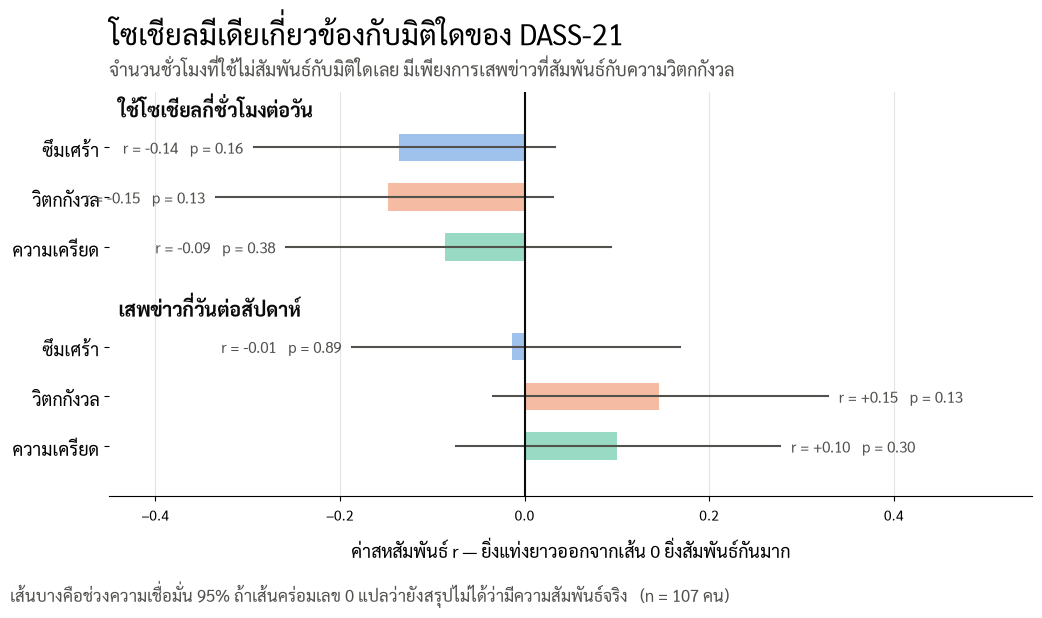

In [7]:
QR2_TITLES = {
    "title": "โซเชียลมีเดียเกี่ยวข้องกับมิติใดของ DASS-21",
    "subtitle": "จำนวนชั่วโมงที่ใช้ไม่สัมพันธ์กับมิติใดเลย มีเพียงการเสพข่าวที่สัมพันธ์กับความวิตกกังวล",
}
QR2_FIG_PATH = FIG_DIR / "qr2-social-media-dass-dimension.png"


def plot_correlations(table: pd.DataFrame) -> None:
    """One bar per exposure x dimension pair: bar length = r, whisker = 95% CI."""
    plt.rcParams["font.family"] = THAI_FONT

    fig, ax = plt.subplots(figsize=(10.5, 6.2))

    # rows top to bottom, one blank slot between the two exposure blocks
    rows = []
    y = 0.0
    for block, exposure in enumerate(EXPOSURE_LABELS.values()):
        if block:
            y -= 1.0
        for dimension in DIMENSIONS.values():
            rows.append((exposure, dimension, y))
            y -= 1.0

    for exposure, dimension, y in rows:
        row = table[
            (table["exposure"] == exposure) & (table["dimension"] == dimension)
        ].iloc[0]
        color = COLOR[dimension]
        significant = row["p"] < 0.05

        ax.barh(
            y,
            row["r"],
            height=0.55,
            color=color,
            alpha=1.0 if significant else 0.45,
            zorder=2,
        )
        ax.plot(
            [row["ci_low"], row["ci_high"]],
            [y, y],
            color="#52514e",
            linewidth=1.5,
            zorder=3,
        )
        # value written out: the reader should not have to measure a bar
        side = 8 if row["r"] >= 0 else -8
        ax.annotate(
            f"r = {row['r']:+.2f}   p = {row['p']:.2f}",
            (max(row["ci_high"], row["r"]) if row["r"] >= 0 else min(row["ci_low"], row["r"]), y),
            textcoords="offset points",
            xytext=(side, 0),
            ha="left" if row["r"] >= 0 else "right",
            va="center",
            fontsize=11,
            color="#0b0b0b" if significant else "#52514e",
        )

    ax.axvline(0, color="#0b0b0b", linewidth=1.5, zorder=4)
    ax.set_yticks([y for _, _, y in rows])
    ax.set_yticklabels([DIMENSION_TH[d] for _, d, _ in rows], fontsize=13)
    ax.set_ylim(min(y for _, _, y in rows) - 1.0, max(y for _, _, y in rows) + 1.1)
    ax.set_xlim(-0.45, 0.55)
    ax.set_xticks(np.arange(-0.4, 0.55, 0.2))
    ax.set_xlabel(
        "ค่าสหสัมพันธ์ r — ยิ่งแท่งยาวออกจากเส้น 0 ยิ่งสัมพันธ์กันมาก",
        fontsize=13,
        labelpad=10,
    )
    ax.grid(axis="x", color="#e5e4e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)

    # block headings stand in for a second axis
    for exposure in EXPOSURE_LABELS.values():
        ys = [y for e, _, y in rows if e == exposure]
        ax.annotate(
            EXPOSURE_TH[exposure],
            (-0.44, max(ys) + 0.6),
            fontsize=14,
            fontweight="bold",
            color="#0b0b0b",
        )

    ax.set_title(QR2_TITLES["title"], loc="left", fontsize=TITLE_SIZE, pad=34)
    ax.annotate(
        QR2_TITLES["subtitle"],
        (0.0, 1.04),
        xycoords="axes fraction",
        fontsize=13,
        color="#52514e",
    )
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    # footnote on the figure, below the axis, so it cannot collide with the label
    fig.text(
        0.012,
        0.02,
        "เส้นบางคือช่วงความเชื่อมั่น 95% ถ้าเส้นคร่อมเลข 0 แปลว่ายังสรุปไม่ได้ว่ามีความสัมพันธ์จริง"
        f"   (n = {int(table['n'].max())} คน)",
        fontsize=12,
        color="#52514e",
    )
    fig.savefig(QR2_FIG_PATH, dpi=200, facecolor="white")
    print(f"saved: {QR2_FIG_PATH}")
    plt.show()


plot_correlations(corr_table)

**อ่านผล**

- **ข้อ 1** ชั่วโมงใช้โซเชียลมีเดียไม่สัมพันธ์กับมิติใดเลย (r = −0.14, −0.15 และ −0.09 ทุกค่า p > 0.05)
  ช่วงความเชื่อมั่นคร่อม 0 ทั้งสามมิติ และ r² ไม่เกิน 0.022 คืออธิบายความแปรปรวนของคะแนนได้ไม่ถึง 3%
- **ข้อ 2** จึงไม่มีมิติใดโดดเด่นกว่ามิติอื่น ค่า |r| ที่มากที่สุดคือชั่วโมงใช้งานกับความวิตกกังวล (−0.15) ซึ่งก็ไม่มีนัยสำคัญ
- **ข้อ 3** การติดตามข่าวสัมพันธ์กับความวิตกกังวล (r = +0.15) มากกว่าภาวะซึมเศร้า (−0.01) และความเครียด (+0.10)
  ตามทิศทางที่คาดไว้ แต่ไม่มีนัยสำคัญ (p = 0.134) และเมื่อหักผลของตัวแปรควบคุมแล้วก็ยังไม่มี (partial r = +0.17, p = 0.103)
- ค่า partial r ใกล้เคียงกับ r ทุกคู่ แปลว่าผลที่ไม่พบนี้ไม่ได้ถูกการนอน เกรด หรือการเงินบดบังไว้